# Credit Score Prediction Model (Poor / Average / Good)

This Jupyter Notebook implements a Logistic Regression classifier to predict credit score categories (Poor, Average, Good) using anonymized financial features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
train_path = "../../DataSet/credit_score/CreditScore_train.csv"
test_path = "../../DataSet/credit_score/CreditScore_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)

Train Shape: (80000, 305)
Test Shape: (20000, 305)


## 2. Target Mapping & Category Definition

We map the continuous credit score `y` to three categories:
- **Poor**: score < 580
- **Average**: 580 <= score < 670
- **Good**: score >= 670

In [3]:
def categorize_score(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Average'
    else:
        return 'Good'

y_train = df_train['y'].apply(categorize_score)
y_test = df_test['y'].apply(categorize_score)

X_train = df_train.drop(columns=['y'])
X_test = df_test.drop(columns=['y'])

print("Target Categories in Train Set:")
print(y_train.value_counts())

Target Categories in Train Set:
y
Poor       35759
Good       27002
Average    17239
Name: count, dtype: int64


## 3. Data Cleaning (Handling Missing Values)

We fill missing values in features using the median values from the train set.

In [4]:
# Fill missing values using the median of training features
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test = X_test.fillna(train_median)

print("Missing values in Train after cleaning:", X_train.isnull().sum().sum())
print("Missing values in Test after cleaning:", X_test.isnull().sum().sum())

Missing values in Train after cleaning: 0
Missing values in Test after cleaning: 0


## 4. Visualize Class Distribution

We create a count plot to visualize the distribution of categories.

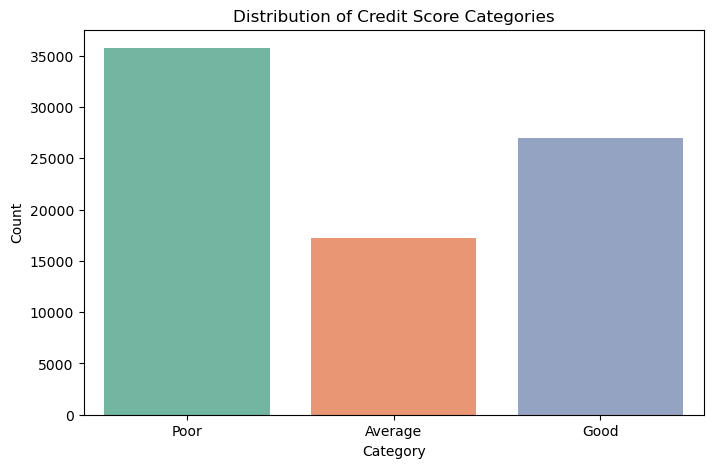

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train, order=['Poor', 'Average', 'Good'], palette='Set2')
plt.title('Distribution of Credit Score Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.savefig('credit_score_distribution.png', dpi=150)
plt.show()

## 5. Model Training & Fitting

We train a Logistic Regression model on our features.

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


## 6. Model Evaluation

We evaluate our model using the `accuracy_score`.

In [7]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("Training Accuracy :", round(accuracy_train * 100, 2), "%")
print("Test Accuracy :", round(accuracy_test * 100, 2), "%")

Training Accuracy : 76.52 %
Test Accuracy : 76.83 %


## 7. Sample Prediction

Let's predict the category for a sample row from the test set.

In [8]:
sample_index = 0
sample_features = X_test.iloc[[sample_index]]
actual_label = y_test.iloc[sample_index]

pred = model.predict(sample_features)[0]
probs = model.predict_proba(sample_features)[0]

print(f"Sample index: {sample_index}")
print(f"Actual Category: {actual_label}")
print(f"Predicted Category: {pred}\n")

print("Probabilities:")
for cls, p in zip(model.classes_, probs):
    print(f"{cls} Probability: {round(p * 100, 2)} %")

Sample index: 0
Actual Category: Poor
Predicted Category: Poor

Probabilities:
Average Probability: 13.98 %
Good Probability: 1.09 %
Poor Probability: 84.94 %
